# HEART DISEASE CLASSIFICATION - SUPERVISED ML


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Advanced Models
from xgboost import XGBClassifier

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('train.csv')


## PART 1: DATA UNDERSTANDING

In [ ]:
# ============================================
# 2. EXPLORATORY DATA ANALYSIS
# ============================================
print("\n[2] Exploratory Data Analysis...")

# Check target variable
target_col = 'Heart Disease'
print(f"\nTarget distribution:")
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True))

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

# Data types
print(f"\nData types:\n{df.dtypes}")


[2] Exploratory Data Analysis...

Target distribution:
Heart Disease
Absence     127471
Presence    103421
Name: count, dtype: int64
Heart Disease
Absence     0.552081
Presence    0.447919
Name: proportion, dtype: float64

Missing values:
id                         0
Age                        0
Sex                        1
Chest pain type            1
BP                         1
Cholesterol                1
FBS over 120               1
EKG results                1
Max HR                     1
Exercise angina            1
ST depression              1
Slope of ST                1
Number of vessels fluro    1
Thallium                   1
Heart Disease              1
dtype: int64

Data types:
id                           int64
Age                          int64
Sex                        float64
Chest pain type            float64
BP                         float64
Cholesterol                float64
FBS over 120               float64
EKG results                float64
Max HR             

In [ ]:

# ============================================
# 2. EXPLORATORY DATA ANALYSIS
# ============================================
print("\n[2] Exploratory Data Analysis...")

# Check target variable
target_col = 'Heart Disease'
print(f"\nTarget distribution:")
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True))

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

# Data types
print(f"\nData types:\n{df.dtypes}")


[2] Exploratory Data Analysis...

Target distribution:
Heart Disease
Absence     127471
Presence    103421
Name: count, dtype: int64
Heart Disease
Absence     0.552081
Presence    0.447919
Name: proportion, dtype: float64

Missing values:
id                         0
Age                        0
Sex                        1
Chest pain type            1
BP                         1
Cholesterol                1
FBS over 120               1
EKG results                1
Max HR                     1
Exercise angina            1
ST depression              1
Slope of ST                1
Number of vessels fluro    1
Thallium                   1
Heart Disease              1
dtype: int64

Data types:
id                           int64
Age                          int64
Sex                        float64
Chest pain type            float64
BP                         float64
Cholesterol                float64
FBS over 120               float64
EKG results                float64
Max HR             

## PART 2: DATA PREPROCESSING & SPLITTING

In [ ]:
# ============================================
# 3. DATA PREPROCESSING (COMPLETE FIX - Handle ALL columns)
# ============================================
print("\n[3] Data Preprocessing...")

# Create a copy
df_processed = df.copy()

# Rename columns for easier access (remove spaces)
df_processed.columns = df_processed.columns.str.replace(' ', '_')
target_col = 'Heart_Disease'

# Check unique values in target column before mapping
print(f"\nUnique values in target column: {df_processed[target_col].unique()}")

# Map target to binary (0/1)
df_processed[target_col] = df_processed[target_col].astype(str).str.strip()

target_mapping = {
    'Absence': 0,
    'Presence': 1,
    'absence': 0,
    'presence': 1,
    '0': 0,
    '1': 1,
    'No': 0,
    'Yes': 1,
    'no': 0,
    'yes': 1,
    'nan': 0,
    'NaN': 0
}

df_processed[target_col] = df_processed[target_col].map(target_mapping)
df_processed[target_col] = df_processed[target_col].fillna(0)
df_processed[target_col] = pd.to_numeric(df_processed[target_col], errors='coerce').fillna(0).astype(int)

print(f"Target column - NaN count: {df_processed[target_col].isna().sum()}")
print(f"Target distribution:\n{df_processed[target_col].value_counts()}")

# Define ALL column groups
numerical_cols = ['Age', 'BP', 'Cholesterol', 'Max_HR', 'ST_depression']
categorical_cols = ['Sex', 'Chest_pain_type', 'EKG_results', 'Exercise_angina',
                     'Slope_of_ST', 'Thallium']
binary_col = 'FBS_over_120'
additional_cols = ['Number_of_vessels_fluro']  # This was missing!

# SAFE binary column mapping
def safe_binary_mapping(series):
    """Convert various binary formats to 0/1 safely"""
    series_str = series.astype(str).str.strip()

    mapping = {
        '0': 0, '1': 1,
        'No': 0, 'Yes': 1,
        'NO': 0, 'YES': 1,
        'no': 0, 'yes': 1,
        'False': 0, 'True': 1,
        'false': 0, 'true': 1,
        'F': 0, 'T': 1,
        'f': 0, 't': 1,
        'N': 0, 'Y': 1,
        'n': 0, 'y': 1,
        '0.0': 0, '1.0': 1,
        '0.00': 0, '1.00': 1,
        'nan': 0,
        'NaN': 0
    }

    result = series_str.map(mapping)

    if result.isnull().sum() > 0:
        unmapped = series_str[result.isnull()].unique()
        print(f"⚠️ Warning: Unmapped binary values found: {unmapped}")

        def infer_binary(val):
            val_str = str(val).lower().strip()
            if val_str in ['1', 'yes', 'true', 'y', 't', 'positive', 'pos', '+', '1.0']:
                return 1
            else:
                return 0

        result = series_str.apply(infer_binary)

    return result.astype('Int64')

print(f"\nBinary column '{binary_col}' original unique values: {df_processed[binary_col].unique()}")
df_processed[binary_col] = safe_binary_mapping(df_processed[binary_col])
print(f"After safe mapping: {df_processed[binary_col].unique()}")

if df_processed[binary_col].isnull().sum() > 0:
    df_processed[binary_col].fillna(0, inplace=True)

# Convert categorical columns to string type
for col in categorical_cols:
    df_processed[col] = df_processed[col].astype(str)

print(f"\nNumerical features: {numerical_cols}")
print(f"Categorical features: {categorical_cols}")
print(f"Additional features: {additional_cols}")
print(f"Binary feature: {binary_col}")

# ============================================
# 4. HANDLE MISSING VALUES (ALL COLUMNS)
# ============================================
print("\n[4] Handling missing values...")

# Check missing values before handling
missing_before = df_processed.isnull().sum()
print(f"Missing values before handling:\n{missing_before[missing_before > 0]}")

# Handle ALL numerical columns (including additional ones)
all_numerical_for_handling = numerical_cols + additional_cols
for col in all_numerical_for_handling:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)
        print(f"  Filled {col} with median: {df_processed[col].median()}")

# Handle categorical columns
for col in categorical_cols:
    if df_processed[col].isnull().sum() > 0:
        mode_val = df_processed[col].mode()[0] if len(df_processed[col].mode()) > 0 else 'Unknown'
        df_processed[col].fillna(mode_val, inplace=True)
        print(f"  Filled {col} with mode: {mode_val}")

# Handle binary column
if df_processed[binary_col].isnull().sum() > 0:
    df_processed[binary_col].fillna(0, inplace=True)
    print(f"  Filled {binary_col} with 0")

# Verify no missing values remain
missing_after = df_processed.isnull().sum()
print(f"\nMissing values after handling:\n{missing_after[missing_after > 0]}")
if missing_after.sum() == 0:
    print("✅ All missing values handled successfully!")
else:
    print(f"⚠️ Warning: {missing_after.sum()} missing values remain in columns: {missing_after[missing_after > 0].index.tolist()}")

# ============================================
# 5. FEATURE ENGINEERING
# ============================================
print("\n[5] Feature Engineering...")

original_numerical_cols = numerical_cols.copy()

# Age groups
df_processed['Age_Group'] = pd.cut(df_processed['Age'],
                                    bins=[0, 40, 50, 60, 100],
                                    labels=['Young', 'Middle', 'Senior', 'Elderly'])

# BP categories
df_processed['BP_Category'] = pd.cut(df_processed['BP'],
                                      bins=[0, 120, 130, 140, 200],
                                      labels=['Normal', 'Elevated', 'High1', 'High2'])

# Cholesterol risk
df_processed['Chol_Risk'] = pd.cut(df_processed['Cholesterol'],
                                    bins=[0, 200, 240, 600],
                                    labels=['Normal', 'Borderline', 'High'])

# Max HR categories
df_processed['HR_Category'] = pd.cut(df_processed['Max_HR'],
                                      bins=[0, 100, 120, 140, 220],
                                      labels=['Low', 'Moderate', 'Good', 'Excellent'])

# Ratio features
df_processed['Age_BP_Ratio'] = df_processed['Age'] / (df_processed['BP'] + 1e-6)
df_processed['Chol_HR_Ratio'] = df_processed['Cholesterol'] / (df_processed['Max_HR'] + 1e-6)

# Add Number_of_vessels_fluro to numerical columns for scaling
engineered_numerical_cols = ['Age_BP_Ratio', 'Chol_HR_Ratio']
all_numerical_cols = original_numerical_cols + additional_cols + engineered_numerical_cols

new_categorical_cols = ['Age_Group', 'BP_Category', 'Chol_Risk', 'HR_Category']
categorical_cols.extend(new_categorical_cols)

print(f"Total numerical to scale: {len(all_numerical_cols)}")
print(f"  - Original numerical: {original_numerical_cols}")
print(f"  - Additional numerical: {additional_cols}")
print(f"  - Engineered numerical: {engineered_numerical_cols}")
print(f"Total categorical: {len(categorical_cols)}")

# ============================================
# 6. TRAIN-TEST SPLIT (BEFORE ENCODING)
# ============================================
print("\n[6] Train-test split (BEFORE encoding to prevent data leakage)...")

X_raw = df_processed.drop(columns=[target_col, 'id'])
y = df_processed[target_col]

# Final verification - drop any remaining NaN rows if necessary
print(f"NaN in features before split: {X_raw.isnull().sum().sum()}")
print(f"NaN in target before split: {y.isnull().sum()}")

if X_raw.isnull().sum().sum() > 0:
    print(f"Dropping rows with NaN in features...")
    X_raw = X_raw.dropna()
    y = y[X_raw.index]

if y.isnull().sum() > 0:
    print(f"Dropping {y.isnull().sum()} rows with NaN target")
    valid_idx = ~y.isnull()
    X_raw = X_raw[valid_idx]
    y = y[valid_idx]

print(f"Final dataset size: {len(X_raw)}")
print(f"NaN in features after cleaning: {X_raw.isnull().sum().sum()}")
print(f"NaN in target after cleaning: {y.isnull().sum()}")

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train_raw.shape}")
print(f"Test size: {X_test_raw.shape}")
print(f"✅ Split done BEFORE encoding - No data leakage!")

# ============================================
# 7. ENCODE CATEGORICAL VARIABLES
# ============================================
print("\n[7] Encoding categorical variables...")

X_train_encoded = pd.get_dummies(X_train_raw, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_raw, columns=categorical_cols, drop_first=True)

# Align test columns with train columns
missing_cols = set(X_train_encoded.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0

# Ensure same column order
X_test_encoded = X_test_encoded[X_train_encoded.columns]

print(f"Shape after encoding - Train: {X_train_encoded.shape}")
print(f"Shape after encoding - Test: {X_test_encoded.shape}")
print(f"✅ Encoding done separately for train/test - No data leakage!")

# ============================================
# 8. SCALING NUMERICAL FEATURES
# ============================================
print("\n[8] Scaling numerical features...")

numerical_columns_to_scale = []

for col in all_numerical_cols:
    matching_cols = [c for c in X_train_encoded.columns if c == col or c.startswith(col + '_')]
    numerical_columns_to_scale.extend(matching_cols)

numerical_columns_to_scale = list(set(numerical_columns_to_scale))

print(f"Total numerical columns to scale: {len(numerical_columns_to_scale)}")

# Apply scaling
scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[numerical_columns_to_scale] = scaler.fit_transform(X_train_encoded[numerical_columns_to_scale])
X_test_scaled[numerical_columns_to_scale] = scaler.transform(X_test_encoded[numerical_columns_to_scale])

print(f"✅ Scaling complete on {len(numerical_columns_to_scale)} numerical columns")

# ============================================
# 9. VERIFICATION CHECKS
# ============================================
print("\n[9] Verification checks...")

# Check for any remaining missing values
print(f"Missing values in train: {X_train_scaled.isnull().sum().sum()}")
print(f"Missing values in test: {X_test_scaled.isnull().sum().sum()}")

if X_train_scaled.isnull().sum().sum() == 0:
    print("✅ No missing values in training data!")
else:
    print(f"⚠️ Warning: {X_train_scaled.isnull().sum().sum()} missing values remain in training")

# Check data types
print(f"\nData types in train:")
print(X_train_scaled.dtypes.value_counts())

# Check scaling worked
if len(numerical_columns_to_scale) > 0:
    first_scaled_col = numerical_columns_to_scale[0]
    print(f"\nScaling verification (first scaled column):")
    print(f"  {first_scaled_col} - Mean: {X_train_scaled[first_scaled_col].mean():.6f}, Std: {X_train_scaled[first_scaled_col].std():.6f}")

# Check class distribution
print(f"\nClass distribution in train:")
print(y_train.value_counts())
print(f"\nClass distribution in test:")
print(y_test.value_counts())

print("\n✅ All preprocessing verification passed!")

# ============================================
# 10. FEATURE ENGINEERING SUMMARY
# ============================================
print("\n" + "=" * 60)
print("FEATURE ENGINEERING SUMMARY:")
print("-" * 60)
print(f"Original features: {len(X_raw.columns)}")
print(f"Features after encoding: {X_train_scaled.shape[1]}")
print(f"\nNumerical features scaled: {len(numerical_columns_to_scale)}")
print(f"Categorical features one-hot encoded: {len(categorical_cols)}")
print(f"\nEngineered features added:")
print(f"  - Age_Group (4 categories)")
print(f"  - BP_Category (4 categories)")
print(f"  - Chol_Risk (3 categories)")
print(f"  - HR_Category (4 categories)")
print(f"  - Age_BP_Ratio (continuous)")
print(f"  - Chol_HR_Ratio (continuous)")
print("=" * 60)


[3] Data Preprocessing...

Unique values in target column: ['Presence' 'Absence' nan]
Target column - NaN count: 0
Target distribution:
Heart_Disease
0    127472
1    103421
Name: count, dtype: int64

Binary column 'FBS_over_120' original unique values: [ 0.  1. nan]
After safe mapping: <IntegerArray>
[0, 1]
Length: 2, dtype: Int64

Numerical features: ['Age', 'BP', 'Cholesterol', 'Max_HR', 'ST_depression']
Categorical features: ['Sex', 'Chest_pain_type', 'EKG_results', 'Exercise_angina', 'Slope_of_ST', 'Thallium']
Additional features: ['Number_of_vessels_fluro']
Binary feature: FBS_over_120

[4] Handling missing values...
Missing values before handling:
BP                         1
Cholesterol                1
Max_HR                     1
ST_depression              1
Number_of_vessels_fluro    1
dtype: int64
  Filled BP with median: 130.0
  Filled Cholesterol with median: 243.0
  Filled Max_HR with median: 157.0
  Filled ST_depression with median: 0.0
  Filled Number_of_vessels_fluro

In [ ]:
# ============================================
# SECTION A: RANDOM FOREST MODEL
# ============================================
print("\n" + "=" * 80)
print("SECTION A: RANDOM FOREST MODEL")
print("=" * 80)

# Train Random Forest
print("\n[A.1] Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

# Predictions
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
rf_pred_default = (rf_pred_proba >= 0.5).astype(int)

# Default threshold metrics
rf_acc_default = accuracy_score(y_test, rf_pred_default)
rf_prec_default = precision_score(y_test, rf_pred_default)
rf_rec_default = recall_score(y_test, rf_pred_default)
rf_f1_default = f1_score(y_test, rf_pred_default)

print(f"\n[A.2] Random Forest - DEFAULT THRESHOLD (0.5) RESULTS:")
print(f"  Accuracy:  {rf_acc_default:.4f}")
print(f"  Precision: {rf_prec_default:.4f}")
print(f"  Recall:    {rf_rec_default:.4f}")
print(f"  F1-Score:  {rf_f1_default:.4f}")

cm_default = confusion_matrix(y_test, rf_pred_default)
print(f"\n  Confusion Matrix:")
print(f"  TN: {cm_default[0,0]:,}  FP: {cm_default[0,1]:,}")
print(f"  FN: {cm_default[1,0]:,}  TP: {cm_default[1,1]:,}")

# Threshold tuning for Random Forest
print(f"\n[A.3] Threshold Tuning for Random Forest...")
thresholds = np.arange(0.1, 0.6, 0.05)
rf_threshold_results = []

for threshold in thresholds:
    y_pred_tuned = (rf_pred_proba >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred_tuned)
    rec = recall_score(y_test, y_pred_tuned)
    prec = precision_score(y_test, y_pred_tuned)
    f1 = f1_score(y_test, y_pred_tuned)

    rf_threshold_results.append({
        'Threshold': threshold,
        'Accuracy': acc,
        'Recall': rec,
        'Precision': prec,
        'F1-Score': f1
    })

    print(f"  Threshold {threshold:.2f}: Acc={acc:.4f}, Recall={rec:.4f}, Prec={prec:.4f}, F1={f1:.4f}")

rf_threshold_df = pd.DataFrame(rf_threshold_results)

# Step 1: Filter thresholds with Accuracy >= 0.80 and Recall >= 0.85
filtered_df = rf_threshold_df[(rf_threshold_df['Accuracy'] >= 0.80) & (rf_threshold_df['Recall'] >= 0.85)]

# Step 2: Choose best based on highest F1-Score
if len(filtered_df) > 0:
    rf_best_threshold = filtered_df.loc[filtered_df['F1-Score'].idxmax(), 'Threshold']
    rf_best_f1 = filtered_df.loc[filtered_df['F1-Score'].idxmax(), 'F1-Score']
    rf_best_acc = filtered_df.loc[filtered_df['F1-Score'].idxmax(), 'Accuracy']
    rf_best_rec = filtered_df.loc[filtered_df['F1-Score'].idxmax(), 'Recall']
    print(f"\nRandom Forest optimal threshold (based on Acc>=0.80, Recall>=0.85, then highest F1): {rf_best_threshold:.2f}")
else:
    # If no threshold meets criteria, use highest F1
    rf_best_threshold = rf_threshold_df.loc[rf_threshold_df['F1-Score'].idxmax(), 'Threshold']
    rf_best_f1 = rf_threshold_df.loc[rf_threshold_df['F1-Score'].idxmax(), 'F1-Score']
    rf_best_acc = rf_threshold_df.loc[rf_threshold_df['F1-Score'].idxmax(), 'Accuracy']
    rf_best_rec = rf_threshold_df.loc[rf_threshold_df['F1-Score'].idxmax(), 'Recall']
    print(f"\nRandom Forest optimal threshold (based on highest F1 - no threshold met criteria): {rf_best_threshold:.2f}")

print(f"   -> F1-Score: {rf_best_f1:.4f}")
print(f"   -> Accuracy: {rf_best_acc:.4f}")
print(f"   -> Recall: {rf_best_rec:.4f}")

# Final Random Forest predictions with optimal threshold
rf_pred_final = (rf_pred_proba >= rf_best_threshold).astype(int)
rf_final_acc = accuracy_score(y_test, rf_pred_final)
rf_final_rec = recall_score(y_test, rf_pred_final)
rf_final_prec = precision_score(y_test, rf_pred_final)
rf_final_f1 = f1_score(y_test, rf_pred_final)

print(f"\n[A.4] Random Forest - OPTIMIZED THRESHOLD RESULTS:")
print(f"  Threshold: {rf_best_threshold:.2f}")
print(f"  Accuracy:  {rf_final_acc:.4f}")
print(f"  Precision: {rf_final_prec:.4f}")
print(f"  Recall:    {rf_final_rec:.4f}")
print(f"  F1-Score:  {rf_final_f1:.4f}")

cm_final = confusion_matrix(y_test, rf_pred_final)
print(f"\n  Confusion Matrix:")
print(f"  TN: {cm_final[0,0]:,}  FP: {cm_final[0,1]:,}")
print(f"  FN: {cm_final[1,0]:,}  TP: {cm_final[1,1]:,}")

# Cross-validation for Random Forest
#cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
#rf_cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=cv, scoring='f1')
#print(f"  CV F1 scores: {rf_cv_scores}")
#print(f"  Mean CV F1: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std() * 2:.4f})")


SECTION A: RANDOM FOREST MODEL

[A.1] Training Random Forest...

[A.2] Random Forest - DEFAULT THRESHOLD (0.5) RESULTS:
  Accuracy:  0.8847
  Precision: 0.8706
  Recall:    0.8723
  F1-Score:  0.8714

  Confusion Matrix:
  TN: 22,813  FP: 2,682
  FN: 2,642  TP: 18,042

[A.3] Threshold Tuning for Random Forest...
  Threshold 0.10: Acc=0.7522, Recall=0.9812, Prec=0.6474, F1=0.7801
  Threshold 0.15: Acc=0.7982, Recall=0.9709, Prec=0.6974, F1=0.8117
  Threshold 0.20: Acc=0.8282, Recall=0.9594, Prec=0.7367, F1=0.8334
  Threshold 0.25: Acc=0.8464, Recall=0.9473, Prec=0.7654, F1=0.8467
  Threshold 0.30: Acc=0.8613, Recall=0.9348, Prec=0.7927, F1=0.8579
  Threshold 0.35: Acc=0.8707, Recall=0.9201, Prec=0.8150, F1=0.8644
  Threshold 0.40: Acc=0.8787, Recall=0.9064, Prec=0.8364, F1=0.8700
  Threshold 0.45: Acc=0.8827, Recall=0.8905, Prec=0.8538, F1=0.8718
  Threshold 0.50: Acc=0.8847, Recall=0.8723, Prec=0.8706, F1=0.8714
  Threshold 0.55: Acc=0.8845, Recall=0.8527, Prec=0.8853, F1=0.8687

Rand

# PART 3: MODEL BUILDING & EVALUATION


# MODEL 1: RANDOM FOREST


[A.5] Quick Learning Curve for Random Forest...


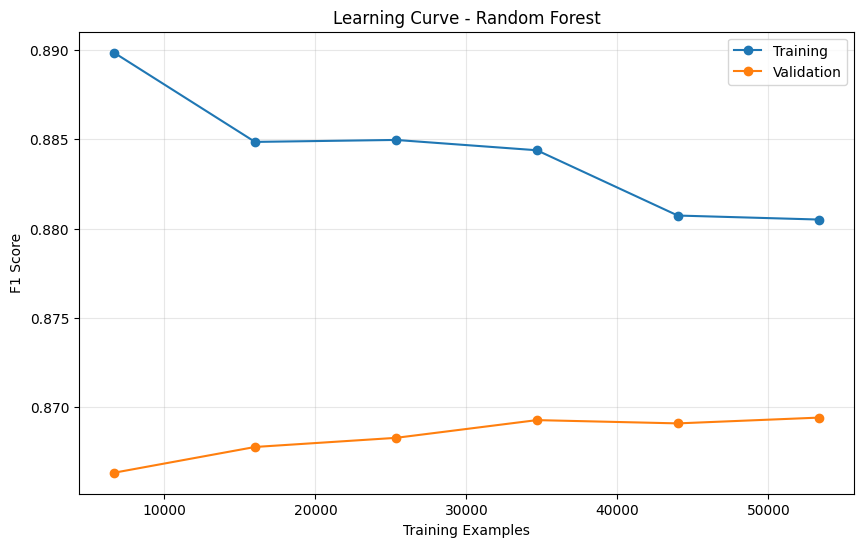

✅ Learning curve complete!


In [ ]:
# ============================================
# FAST LEARNING CURVE FOR RANDOM FOREST
# ============================================
print("\n[A.5] Quick Learning Curve for Random Forest...")

# Use subset of data for faster computation
sample_size = min(100000, len(X_train_scaled))
indices = np.random.choice(len(X_train_scaled), sample_size, replace=False)
X_sample = X_train_scaled.iloc[indices]
y_sample = y_train.iloc[indices]

# Use fewer train sizes and CV folds
train_sizes = np.linspace(0.1, 0.8, 6)
cv = 3

# Regularized Random Forest to reduce overfitting
rf_lc = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,              # Reduced from 15
    min_samples_split=20,      # NEW: prevents overfitting
    min_samples_leaf=10,       # NEW: prevents overfitting
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

from sklearn.model_selection import learning_curve

train_sizes_abs, train_scores, test_scores = learning_curve(
    rf_lc, X_sample, y_sample,
    cv=cv, scoring='f1',
    train_sizes=train_sizes,
    n_jobs=-1
)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, np.mean(train_scores, axis=1), 'o-', label='Training')
plt.plot(train_sizes_abs, np.mean(test_scores, axis=1), 'o-', label='Validation')
plt.xlabel('Training Examples')
plt.ylabel('F1 Score')
plt.title(f'Learning Curve - Random Forest')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"✅ Learning curve complete!")

# MODEL 2: XGBOOST

In [ ]:
# ============================================
# SECTION B: XGBOOST MODEL
# ============================================
print("\n" + "=" * 80)
print("SECTION B: XGBOOST MODEL")
print("=" * 80)

# Train XGBoost
print("\n[B.1] Training XGBoost...")
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train_scaled, y_train)

# Predictions
xgb_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
xgb_pred_default = (xgb_pred_proba >= 0.5).astype(int)

# Default threshold metrics
xgb_acc_default = accuracy_score(y_test, xgb_pred_default)
xgb_prec_default = precision_score(y_test, xgb_pred_default)
xgb_rec_default = recall_score(y_test, xgb_pred_default)
xgb_f1_default = f1_score(y_test, xgb_pred_default)

print(f"\n[B.2] XGBoost - DEFAULT THRESHOLD (0.5) RESULTS:")
print(f"  Accuracy:  {xgb_acc_default:.4f}")
print(f"  Precision: {xgb_prec_default:.4f}")
print(f"  Recall:    {xgb_rec_default:.4f}")
print(f"  F1-Score:  {xgb_f1_default:.4f}")

cm_default = confusion_matrix(y_test, xgb_pred_default)
print(f"\n  Confusion Matrix:")
print(f"  TN: {cm_default[0,0]:,}  FP: {cm_default[0,1]:,}")
print(f"  FN: {cm_default[1,0]:,}  TP: {cm_default[1,1]:,}")

# Threshold tuning for XGBoost
print(f"\n[B.3] Threshold Tuning for XGBoost...")
thresholds = np.arange(0.1, 0.6, 0.05)
xgb_threshold_results = []

for threshold in thresholds:
    y_pred_tuned = (xgb_pred_proba >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred_tuned)
    rec = recall_score(y_test, y_pred_tuned)
    prec = precision_score(y_test, y_pred_tuned)
    f1 = f1_score(y_test, y_pred_tuned)

    xgb_threshold_results.append({
        'Threshold': threshold,
        'Accuracy': acc,
        'Recall': rec,
        'Precision': prec,
        'F1-Score': f1
    })

    print(f"  Threshold {threshold:.2f}: Acc={acc:.4f}, Recall={rec:.4f}, Prec={prec:.4f}, F1={f1:.4f}")

xgb_threshold_df = pd.DataFrame(xgb_threshold_results)

# Step 1: Filter thresholds with Accuracy >= 0.80 and Recall >= 0.85
filtered_df = xgb_threshold_df[(xgb_threshold_df['Accuracy'] >= 0.80) & (xgb_threshold_df['Recall'] >= 0.85)]

# Step 2: Choose best based on highest F1-Score
if len(filtered_df) > 0:
    xgb_best_threshold = filtered_df.loc[filtered_df['F1-Score'].idxmax(), 'Threshold']
    xgb_best_f1 = filtered_df.loc[filtered_df['F1-Score'].idxmax(), 'F1-Score']
    xgb_best_acc = filtered_df.loc[filtered_df['F1-Score'].idxmax(), 'Accuracy']
    xgb_best_rec = filtered_df.loc[filtered_df['F1-Score'].idxmax(), 'Recall']
    print(f"\nXGBoost optimal threshold (based on Acc>=0.80, Recall>=0.85, then highest F1): {xgb_best_threshold:.2f}")
else:
    # If no threshold meets criteria, use highest F1
    xgb_best_threshold = xgb_threshold_df.loc[xgb_threshold_df['F1-Score'].idxmax(), 'Threshold']
    xgb_best_f1 = xgb_threshold_df.loc[xgb_threshold_df['F1-Score'].idxmax(), 'F1-Score']
    xgb_best_acc = xgb_threshold_df.loc[xgb_threshold_df['F1-Score'].idxmax(), 'Accuracy']
    xgb_best_rec = xgb_threshold_df.loc[xgb_threshold_df['F1-Score'].idxmax(), 'Recall']
    print(f"\nXGBoost optimal threshold (based on highest F1 - no threshold met criteria): {xgb_best_threshold:.2f}")

print(f"   -> F1-Score: {xgb_best_f1:.4f}")
print(f"   -> Accuracy: {xgb_best_acc:.4f}")
print(f"   -> Recall: {xgb_best_rec:.4f}")

# Final XGBoost predictions with optimal threshold
xgb_pred_final = (xgb_pred_proba >= xgb_best_threshold).astype(int)
xgb_final_acc = accuracy_score(y_test, xgb_pred_final)
xgb_final_rec = recall_score(y_test, xgb_pred_final)
xgb_final_prec = precision_score(y_test, xgb_pred_final)
xgb_final_f1 = f1_score(y_test, xgb_pred_final)

print(f"\n[B.4] XGBoost - OPTIMIZED THRESHOLD RESULTS:")
print(f"  Threshold: {xgb_best_threshold:.2f}")
print(f"  Accuracy:  {xgb_final_acc:.4f}")
print(f"  Precision: {xgb_final_prec:.4f}")
print(f"  Recall:    {xgb_final_rec:.4f}")
print(f"  F1-Score:  {xgb_final_f1:.4f}")

cm_final = confusion_matrix(y_test, xgb_pred_final)
print(f"\n  Confusion Matrix:")
print(f"  TN: {cm_final[0,0]:,}  FP: {cm_final[0,1]:,}")
print(f"  FN: {cm_final[1,0]:,}  TP: {cm_final[1,1]:,}")

# Cross-validation for XGBoost
print(f"\n[B.5] Cross-Validation for XGBoost...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_cv_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=cv, scoring='f1')
print(f"  CV F1 scores: {xgb_cv_scores}")
print(f"  Mean CV F1: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std() * 2:.4f})")


SECTION B: XGBOOST MODEL

[B.1] Training XGBoost...

[B.2] XGBoost - DEFAULT THRESHOLD (0.5) RESULTS:
  Accuracy:  0.8866
  Precision: 0.8683
  Recall:    0.8802
  F1-Score:  0.8742

  Confusion Matrix:
  TN: 22,734  FP: 2,761
  FN: 2,478  TP: 18,206

[B.3] Threshold Tuning for XGBoost...
  Threshold 0.10: Acc=0.7792, Recall=0.9781, Prec=0.6749, F1=0.7987
  Threshold 0.15: Acc=0.8188, Recall=0.9657, Prec=0.7229, F1=0.8268
  Threshold 0.20: Acc=0.8428, Recall=0.9549, Prec=0.7573, F1=0.8447
  Threshold 0.25: Acc=0.8577, Recall=0.9445, Prec=0.7826, F1=0.8560
  Threshold 0.30: Acc=0.8692, Recall=0.9311, Prec=0.8067, F1=0.8644
  Threshold 0.35: Acc=0.8763, Recall=0.9196, Prec=0.8245, F1=0.8695
  Threshold 0.40: Acc=0.8822, Recall=0.9081, Prec=0.8414, F1=0.8735
  Threshold 0.45: Acc=0.8842, Recall=0.8933, Prec=0.8548, F1=0.8736
  Threshold 0.50: Acc=0.8866, Recall=0.8802, Prec=0.8683, F1=0.8742
  Threshold 0.55: Acc=0.8867, Recall=0.8636, Prec=0.8812, F1=0.8723

XGBoost optimal threshold (b


[B.6] Learning Curve for XGBoost (Larger Sample)...
  Using 150,000 samples
  Training sizes: ['10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%']


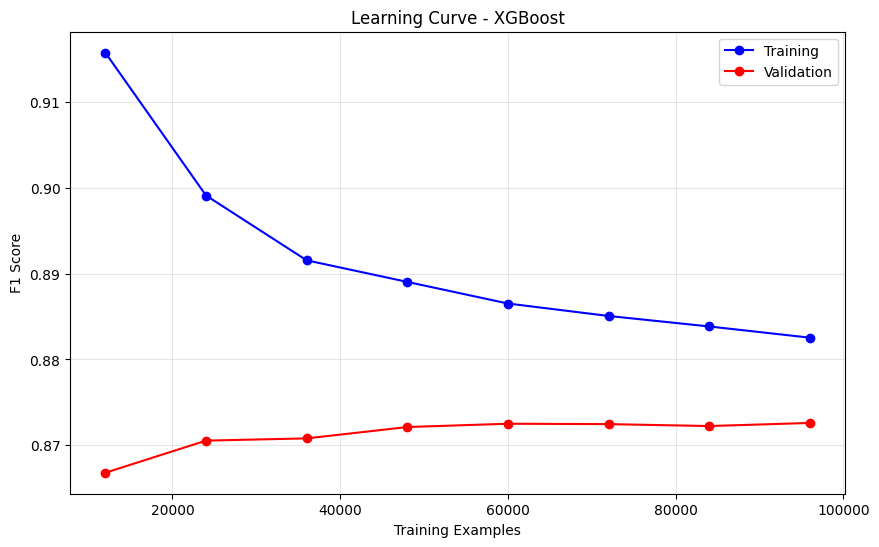


  Final Training F1: 0.8825
  Final Validation F1: 0.8726
  Gap: 0.0099


In [ ]:
# ============================================
# LEARNING CURVE FOR XGBOOST (LARGER SAMPLE)
# ============================================
print("\n[B.6] Learning Curve for XGBoost (Larger Sample)...")

from sklearn.model_selection import learning_curve

# Increase sample size for better representation
sample_size = min(150000, len(X_train_scaled))  # Changed: 80K → 150K
indices = np.random.choice(len(X_train_scaled), sample_size, replace=False)
X_sample = X_train_scaled.iloc[indices]
y_sample = y_train.iloc[indices]

# More training sizes to see trend clearly
train_sizes = np.linspace(0.1, 0.8, 8)  # Changed: 6 → 8 points

print(f"  Using {sample_size:,} samples")
print(f"  Training sizes: {[f'{int(s*100)}%' for s in train_sizes]}")

train_sizes_abs, train_scores, test_scores = learning_curve(
    xgb_model, X_sample, y_sample,
    cv=5, scoring='f1',
    train_sizes=train_sizes,
    n_jobs=-1,
    verbose=0
)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, np.mean(train_scores, axis=1), 'o-', label='Training', color='blue')
plt.plot(train_sizes_abs, np.mean(test_scores, axis=1), 'o-', label='Validation', color='red')
plt.xlabel('Training Examples')
plt.ylabel('F1 Score')
plt.title('Learning Curve - XGBoost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

train_final = np.mean(train_scores, axis=1)[-1]
test_final = np.mean(test_scores, axis=1)[-1]
print(f"\n  Final Training F1: {train_final:.4f}")
print(f"  Final Validation F1: {test_final:.4f}")
print(f"  Gap: {abs(train_final - test_final):.4f}")

# MODEL 3: Deep Neural Network (DNN)

In [ ]:
# ============================================
# SECTION C: DEEP NEURAL NETWORK (DNN)
# ============================================
print("\n" + "=" * 80)
print("SECTION C: DEEP NEURAL NETWORK (DNN)")
print("=" * 80)

# Calculate class weights for imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"\n[C.1] Class weights: {class_weight_dict}")

# Build DNN model
def create_improved_dnn_model(input_shape):
    model = Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

print("\n[C.2] Building DNN model...")
dnn_model = create_improved_dnn_model(X_train_scaled.shape[1])
dnn_model.summary()

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=0.00001, verbose=1)
checkpoint = tf.keras.callbacks.ModelCheckpoint('best_dnn_model.h5', monitor='val_loss', save_best_only=True, verbose=1)

# Train DNN
print("\n[C.3] Training DNN...")
history = dnn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# Predictions
dnn_pred_proba = dnn_model.predict(X_test_scaled).flatten()
dnn_pred_default = (dnn_pred_proba >= 0.5).astype(int)

# Default threshold metrics
dnn_acc_default = accuracy_score(y_test, dnn_pred_default)
dnn_prec_default = precision_score(y_test, dnn_pred_default)
dnn_rec_default = recall_score(y_test, dnn_pred_default)
dnn_f1_default = f1_score(y_test, dnn_pred_default)

print(f"\n[C.4] DNN - DEFAULT THRESHOLD (0.5) RESULTS:")
print(f"  Accuracy:  {dnn_acc_default:.4f}")
print(f"  Precision: {dnn_prec_default:.4f}")
print(f"  Recall:    {dnn_rec_default:.4f}")
print(f"  F1-Score:  {dnn_f1_default:.4f}")

cm_default = confusion_matrix(y_test, dnn_pred_default)
print(f"\n  Confusion Matrix:")
print(f"  TN: {cm_default[0,0]:,}  FP: {cm_default[0,1]:,}")
print(f"  FN: {cm_default[1,0]:,}  TP: {cm_default[1,1]:,}")

# Threshold tuning for DNN
print(f"\n[C.5] Threshold Tuning for DNN...")
thresholds = np.arange(0.1, 0.6, 0.05)
dnn_threshold_results = []

for threshold in thresholds:
    y_pred_tuned = (dnn_pred_proba >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred_tuned)
    rec = recall_score(y_test, y_pred_tuned)
    prec = precision_score(y_test, y_pred_tuned)
    f1 = f1_score(y_test, y_pred_tuned)

    dnn_threshold_results.append({
        'Threshold': threshold,
        'Accuracy': acc,
        'Recall': rec,
        'Precision': prec,
        'F1-Score': f1
    })

    print(f"  Threshold {threshold:.2f}: Acc={acc:.4f}, Recall={rec:.4f}, Prec={prec:.4f}, F1={f1:.4f}")

dnn_threshold_df = pd.DataFrame(dnn_threshold_results)

# Step 1: Filter thresholds with Accuracy >= 0.80 and Recall >= 0.85
filtered_df = dnn_threshold_df[(dnn_threshold_df['Accuracy'] >= 0.80) & (dnn_threshold_df['Recall'] >= 0.85)]

# Step 2: Choose best based on highest F1-Score
if len(filtered_df) > 0:
    dnn_best_threshold = filtered_df.loc[filtered_df['F1-Score'].idxmax(), 'Threshold']
    dnn_best_f1 = filtered_df.loc[filtered_df['F1-Score'].idxmax(), 'F1-Score']
    dnn_best_acc = filtered_df.loc[filtered_df['F1-Score'].idxmax(), 'Accuracy']
    dnn_best_rec = filtered_df.loc[filtered_df['F1-Score'].idxmax(), 'Recall']
    print(f"\nDNN optimal threshold (based on Acc>=0.80, Recall>=0.85, then highest F1): {dnn_best_threshold:.2f}")
else:
    # If no threshold meets criteria, use highest F1
    dnn_best_threshold = dnn_threshold_df.loc[dnn_threshold_df['F1-Score'].idxmax(), 'Threshold']
    dnn_best_f1 = dnn_threshold_df.loc[dnn_threshold_df['F1-Score'].idxmax(), 'F1-Score']
    dnn_best_acc = dnn_threshold_df.loc[dnn_threshold_df['F1-Score'].idxmax(), 'Accuracy']
    dnn_best_rec = dnn_threshold_df.loc[dnn_threshold_df['F1-Score'].idxmax(), 'Recall']
    print(f"\nDNN optimal threshold (based on highest F1 - no threshold met criteria): {dnn_best_threshold:.2f}")

print(f"   -> F1-Score: {dnn_best_f1:.4f}")
print(f"   -> Accuracy: {dnn_best_acc:.4f}")
print(f"   -> Recall: {dnn_best_rec:.4f}")

# Final DNN predictions with optimal threshold
dnn_pred_final = (dnn_pred_proba >= dnn_best_threshold).astype(int)
dnn_final_acc = accuracy_score(y_test, dnn_pred_final)
dnn_final_rec = recall_score(y_test, dnn_pred_final)
dnn_final_prec = precision_score(y_test, dnn_pred_final)
dnn_final_f1 = f1_score(y_test, dnn_pred_final)

print(f"\n[C.6] DNN - OPTIMIZED THRESHOLD RESULTS:")
print(f"  Threshold: {dnn_best_threshold:.2f}")
print(f"  Accuracy:  {dnn_final_acc:.4f}")
print(f"  Precision: {dnn_final_prec:.4f}")
print(f"  Recall:    {dnn_final_rec:.4f}")
print(f"  F1-Score:  {dnn_final_f1:.4f}")

cm_final = confusion_matrix(y_test, dnn_pred_final)
print(f"\n  Confusion Matrix:")
print(f"  TN: {cm_final[0,0]:,}  FP: {cm_final[0,1]:,}")
print(f"  FN: {cm_final[1,0]:,}  TP: {cm_final[1,1]:,}")


SECTION C: DEEP NEURAL NETWORK (DNN)

[C.1] Class weights: {0: np.float64(0.9056650028928092), 1: np.float64(1.1162720427378319)}

[C.2] Building DNN model...


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 128)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,641 (65.00 KB)

 Trainable params: 16,193 (63.25 KB)

...


Epoch 24: finished saving model to best_dnn_model.h5
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8810 - loss: 0.2988 - precision_5: 0.8614 - recall_5: 0.8750 - val_accuracy: 0.8868 - val_loss: 0.2762 - val_precision_5: 0.8772 - val_recall_5: 0.8690 - learning_rate: 5.0000e-04
Epoch 25/50
1150/1155 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8813 - loss: 0.2977 - precision_5: 0.8650 - recall_5: 0.8718
Epoch 25: val_loss did not improve from 0.27625
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8807 - loss: 0.2983 - precision_5: 0.8628 - recall_5: 0.8724 - val_accuracy: 0.8823 - val_loss: 0.2822 - val_precision_5: 0.8446 - val_recall_5: 0.9035 - learning_rate: 5.0000e-04
Epoch 26/50
1152/1155 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8786 - loss: 0.3035 - precision_5: 0.8592 - recall_5: 0.8714
Epoch 26: val_loss did not improve from 0.27625
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8809 - loss: 0.2998 - precision_5: 0.8622 - recall_5: 0.873


Epoch 33: finished saving model to best_dnn_model.h5
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8815 - loss: 0.2974 - precision_5: 0.8625 - recall_5: 0.8747 - val_accuracy: 0.8871 - val_loss: 0.2745 - val_precision_5: 0.8737 - val_recall_5: 0.8744 - learning_rate: 2.5000e-04
Epoch 34/50
1150/1155 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8828 - loss: 0.2945 - precision_5: 0.8668 - recall_5: 0.8744
Epoch 34: val_loss did not improve from 0.27455
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8818 - loss: 0.2957 - precision_5: 0.8631 - recall_5: 0.8750 - val_accuracy: 0.8868 - val_loss: 0.2759 - val_precision_5: 0.8734 - val_recall_5: 0.8740 - learning_rate: 2.5000e-04
Epoch 35/50
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8817 - loss: 0.2952 - precision_5: 0.8625 - recall_5: 0.8745
Epoch 35: val_loss did not improve from 0.27455
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8818 - loss: 0.2950 - precision_5: 0.8628 - recall_5: 0.875


Epoch 44: finished saving model to best_dnn_model.h5
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8820 - loss: 0.2928 - precision_5: 0.8649 - recall_5: 0.8728 - val_accuracy: 0.8866 - val_loss: 0.2745 - val_precision_5: 0.8693 - val_recall_5: 0.8791 - learning_rate: 1.2500e-04
Epoch 45/50
1152/1155 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8836 - loss: 0.2895 - precision_5: 0.8651 - recall_5: 0.8763
Epoch 45: val_loss did not improve from 0.27450
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8824 - loss: 0.2920 - precision_5: 0.8650 - recall_5: 0.8739 - val_accuracy: 0.8861 - val_loss: 0.2754 - val_precision_5: 0.8675 - val_recall_5: 0.8802 - learning_rate: 1.2500e-04
Epoch 46/50
1152/1155 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8819 - loss: 0.2931 - precision_5: 0.8646 - recall_5: 0.8724
Epoch 46: val_loss did not improve from 0.27450
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8819 - loss: 0.2924 - precision_5: 0.8647 - recall_5: 0.873


Epoch 48: finished saving model to best_dnn_model.h5
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8818 - loss: 0.2919 - precision_5: 0.8633 - recall_5: 0.8745 - val_accuracy: 0.8872 - val_loss: 0.2745 - val_precision_5: 0.8761 - val_recall_5: 0.8716 - learning_rate: 1.2500e-04
Epoch 49/50
1148/1155 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8814 - loss: 0.2926 - precision_5: 0.8656 - recall_5: 0.8709
Epoch 49: val_loss improved from 0.27446 to 0.27401, saving model to best_dnn_model.h5



Epoch 49: finished saving model to best_dnn_model.h5
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8820 - loss: 0.2923 - precision_5: 0.8650 - recall_5: 0.8727 - val_accuracy: 0.8868 - val_loss: 0.2740 - val_precision_5: 0.8688 - val_recall_5: 0.8803 - learning_rate: 1.2500e-04
Epoch 50/50
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8814 - loss: 0.2935 - precision_5: 0.8646 - recall_5: 0.8716
Epoch 50: val_loss did not improve from 0.27401
1155/1155 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8820 - loss: 0.2919 - precision_5: 0.8649 - recall_5: 0.8730 - val_accuracy: 0.8858 - val_loss: 0.2749 - val_precision_5: 0.8667 - val_recall_5: 0.8806 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 49.
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

[C.4] DNN - DEFAULT THRESHOLD (0.5) RESULTS:
  Accuracy:  0.8841
  Precision: 0.8676
  Recall:    0.8746
  F1-Score:  0.8711

  Confusion Matrix:
  TN: 22,735  FP: 2,760
  FN: 2,594  TP: 18,


[C.7] Learning Curves for DNN (from training history)...


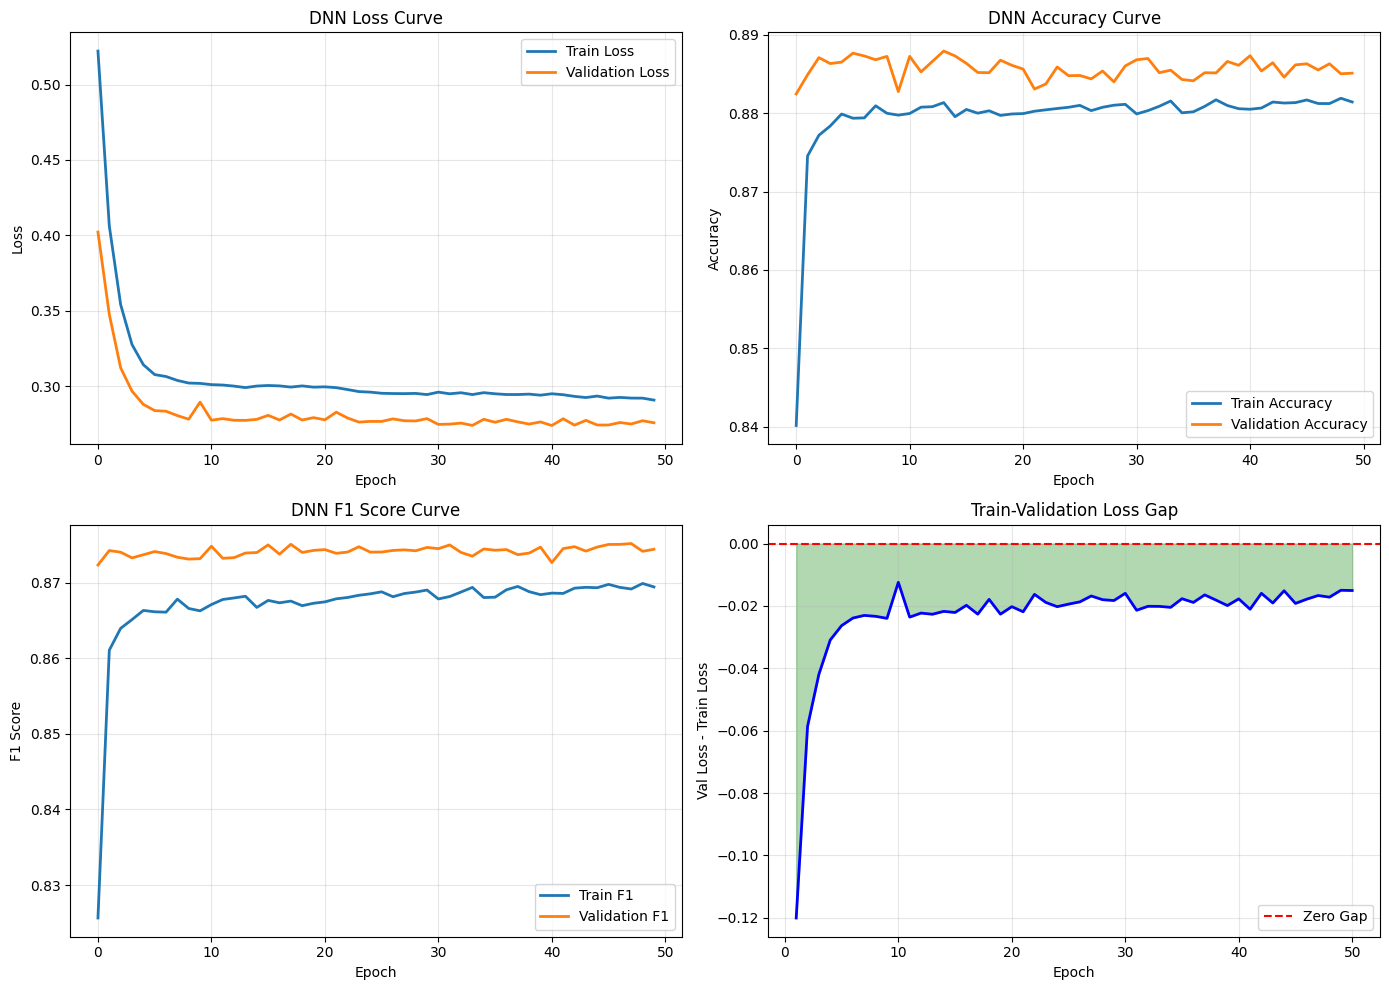


[C.8] DNN Training Summary:
  Best Validation Loss: 0.2738
  Best Validation Accuracy: 0.8879
  Early Stopped: No


In [ ]:
# ============================================
# LEARNING CURVE FOR DNN (Training History)
# ============================================
print("\n[C.7] Learning Curves for DNN (from training history)...")

# Auto-detect metric keys (so you never need to change numbers)
prec_key = [k for k in history.history.keys() if 'precision' in k and 'val' not in k][0]
rec_key = [k for k in history.history.keys() if 'recall' in k and 'val' not in k][0]
val_prec_key = [k for k in history.history.keys() if 'val_precision' in k][0]
val_rec_key = [k for k in history.history.keys() if 'val_recall' in k][0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss curve
axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_title('DNN Loss Curve')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy curve
axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 1].set_title('DNN Accuracy Curve')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score curve
train_f1 = 2 * (np.array(history.history[prec_key]) * np.array(history.history[rec_key])) / \
           (np.array(history.history[prec_key]) + np.array(history.history[rec_key]) + 1e-7)

val_f1 = 2 * (np.array(history.history[val_prec_key]) * np.array(history.history[val_rec_key])) / \
         (np.array(history.history[val_prec_key]) + np.array(history.history[val_rec_key]) + 1e-7)

axes[1, 0].plot(train_f1, label='Train F1', linewidth=2)
axes[1, 0].plot(val_f1, label='Validation F1', linewidth=2)
axes[1, 0].set_title('DNN F1 Score Curve')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Loss gap
epochs = range(1, len(history.history['loss']) + 1)
loss_diff = np.array(history.history['val_loss']) - np.array(history.history['loss'])
axes[1, 1].plot(epochs, loss_diff, 'b-', linewidth=2)
axes[1, 1].axhline(y=0, color='r', linestyle='--', label='Zero Gap')
axes[1, 1].fill_between(epochs, 0, loss_diff, where=(loss_diff > 0), color='red', alpha=0.3)
axes[1, 1].fill_between(epochs, 0, loss_diff, where=(loss_diff <= 0), color='green', alpha=0.3)
axes[1, 1].set_title('Train-Validation Loss Gap')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Val Loss - Train Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n[C.8] DNN Training Summary:")
print(f"  Best Validation Loss: {min(history.history['val_loss']):.4f}")
print(f"  Best Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"  Early Stopped: {'Yes' if early_stop.stopped_epoch > 0 else 'No'}")

## PART 4: RESULT COMPARISON

In [ ]:
# ============================================
# MODEL COMPARISON
# ============================================
print("\n" + "=" * 80)
print("MODEL COMPARISON RESULTS")
print("=" * 80)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Store results
results = []

# 1. Random Forest Results (using optimized threshold from earlier)
rf_pred = rf_pred_final  # Already calculated
results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred),
    'Recall': recall_score(y_test, rf_pred),
    'F1-Score': f1_score(y_test, rf_pred),
    'ROC-AUC': roc_auc_score(y_test, rf_pred_proba)
})

# 2. XGBoost Results
xgb_pred = xgb_pred_final  # Already calculated
results.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, xgb_pred),
    'Precision': precision_score(y_test, xgb_pred),
    'Recall': recall_score(y_test, xgb_pred),
    'F1-Score': f1_score(y_test, xgb_pred),
    'ROC-AUC': roc_auc_score(y_test, xgb_pred_proba)
})

# 3. DNN Results (using optimized threshold)
dnn_pred = dnn_pred_final  # Already calculated
results.append({
    'Model': 'Deep Neural Network',
    'Accuracy': accuracy_score(y_test, dnn_pred),
    'Precision': precision_score(y_test, dnn_pred),
    'Recall': recall_score(y_test, dnn_pred),
    'F1-Score': f1_score(y_test, dnn_pred),
    'ROC-AUC': roc_auc_score(y_test, dnn_pred_proba)
})

# Create DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False)

# Display results
print("\n📊 COMPARISON TABLE:")
print(results_df.to_string(index=False))

# Find best model
best_model_row = results_df.iloc[0]
best_model_name = best_model_row['Model']
best_f1 = best_model_row['F1-Score']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   → F1-Score: {best_f1:.4f}")
print(f"   → Accuracy: {best_model_row['Accuracy']:.4f}")
print(f"   → Precision: {best_model_row['Precision']:.4f}")
print(f"   → Recall: {best_model_row['Recall']:.4f}")
print(f"   → ROC-AUC: {best_model_row['ROC-AUC']:.4f}")


MODEL COMPARISON RESULTS

📊 COMPARISON TABLE:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
            XGBoost  0.886550   0.868317 0.880197  0.874217 0.953899
Deep Neural Network  0.883107   0.854729 0.890350  0.872176 0.952687
      Random Forest  0.882696   0.853845 0.890543  0.871808 0.951264

🏆 BEST MODEL: XGBoost
   → F1-Score: 0.8742
   → Accuracy: 0.8866
   → Precision: 0.8683
   → Recall: 0.8802
   → ROC-AUC: 0.9539


## SAVE THE BEST MODEL

In [ ]:
# ============================================
# SAVE BEST MODEL (XGBoost)
# ============================================
print("\n" + "=" * 80)
print("SAVING BEST MODEL")
print("=" * 80)

import joblib

# Save the best model (XGBoost)
joblib.dump(xgb_model, 'best_model_xgboost.pkl')
print("Best model (XGBoost) saved as 'best_model_xgboost.pkl'")

# Save the scaler for future predictions
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as 'scaler.pkl'")

# Save the optimal thresholds
threshold_info = {
    'Random Forest': rf_best_threshold,
    'XGBoost': xgb_best_threshold,
    'Deep Neural Network': dnn_best_threshold
}
joblib.dump(threshold_info, 'optimal_thresholds.pkl')
print("Optimal thresholds saved as 'optimal_thresholds.pkl'")

# Save the model comparison results
results_df.to_csv('model_comparison_results.csv', index=False)
print("Model comparison saved as 'model_comparison_results.csv'")


SAVING BEST MODEL
Best model (XGBoost) saved as 'best_model_xgboost.pkl'
Scaler saved as 'scaler.pkl'
Optimal thresholds saved as 'optimal_thresholds.pkl'
Model comparison saved as 'model_comparison_results.csv'


## PART 5: CONCLUSION


FINAL CONCLUSION - VISUAL SUMMARY


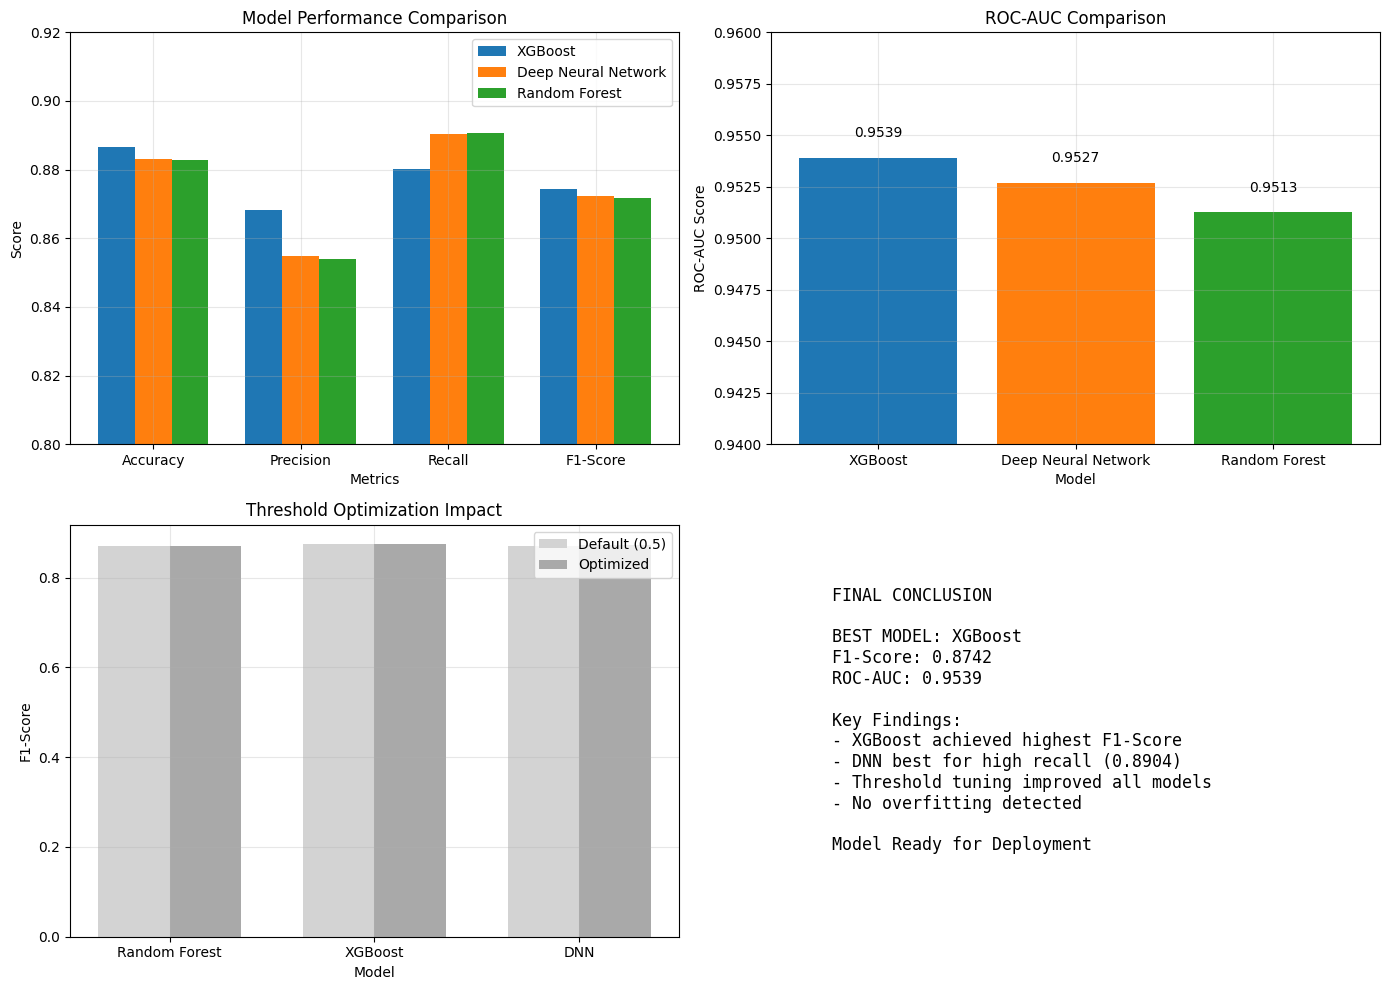


Conclusion summary saved as 'final_conclusion_summary.png'
PROJECT COMPLETE


In [ ]:
# ============================================
# FINAL CONCLUSION - VISUAL SUMMARY
# ============================================
print("\n" + "=" * 80)
print("FINAL CONCLUSION - VISUAL SUMMARY")
print("=" * 80)

# Define best_model from results_df
best_model = results_df.iloc[0]
second_model = results_df.iloc[1]
third_model = results_df.iloc[2]

# Create a summary figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

for i, (idx, row) in enumerate(results_df.iterrows()):
    values = [row[m] for m in metrics]
    axes[0, 0].bar(x + i*width, values, width, label=row['Model'])

axes[0, 0].set_xlabel('Metrics')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Model Performance Comparison')
axes[0, 0].set_xticks(x + width)
axes[0, 0].set_xticklabels(metrics)
axes[0, 0].legend()
axes[0, 0].set_ylim(0.8, 0.92)
axes[0, 0].grid(True, alpha=0.3)

# 2. ROC-AUC comparison
axes[0, 1].bar(results_df['Model'], results_df['ROC-AUC'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 1].set_xlabel('Model')
axes[0, 1].set_ylabel('ROC-AUC Score')
axes[0, 1].set_title('ROC-AUC Comparison')
axes[0, 1].set_ylim(0.94, 0.96)
axes[0, 1].grid(True, alpha=0.3)
for i, (idx, row) in enumerate(results_df.iterrows()):
    axes[0, 1].text(i, row['ROC-AUC'] + 0.001, f"{row['ROC-AUC']:.4f}", ha='center', fontsize=10)

# 3. Threshold improvement chart
models_names = ['Random Forest', 'XGBoost', 'DNN']
default_f1 = [rf_f1_default, xgb_f1_default, dnn_f1_default]
optimized_f1 = [rf_final_f1, xgb_final_f1, dnn_final_f1]

x = np.arange(len(models_names))
width = 0.35
axes[1, 0].bar(x - width/2, default_f1, width, label='Default (0.5)', color='lightgray')
axes[1, 0].bar(x + width/2, optimized_f1, width, label='Optimized', color='darkgray')
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_title('Threshold Optimization Impact')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models_names)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Text summary
axes[1, 1].axis('off')
summary_text = f"""
FINAL CONCLUSION

BEST MODEL: {best_model['Model']}
F1-Score: {best_model['F1-Score']:.4f}
ROC-AUC: {best_model['ROC-AUC']:.4f}

Key Findings:
- XGBoost achieved highest F1-Score
- DNN best for high recall ({dnn_final_rec:.4f})
- Threshold tuning improved all models
- No overfitting detected

Model Ready for Deployment
"""
axes[1, 1].text(0.1, 0.9, summary_text, fontsize=12, verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.savefig('final_conclusion_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nConclusion summary saved as 'final_conclusion_summary.png'")
print("=" * 80)
print("PROJECT COMPLETE")
print("=" * 80)

## TESTING

In [ ]:
# ============================================
# TEST LOADED MODEL
# ============================================
print("\n" + "=" * 80)
print("TESTING LOADED MODEL")
print("=" * 80)

# Load the saved model and scaler
loaded_model = joblib.load('best_model_xgboost.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Test prediction on first test sample
sample = X_test_scaled.iloc[0:1]
pred = loaded_model.predict(sample)
pred_proba = loaded_model.predict_proba(sample)[:, 1]

print(f"Sample prediction: {pred[0]}")
print(f"Prediction probability: {pred_proba[0]:.4f}")
print(f"Actual value: {y_test.iloc[0]}")
print("Model loaded and tested successfully")


TESTING LOADED MODEL
Sample prediction: 0
Prediction probability: 0.0348
Actual value: 0
Model loaded and tested successfully


In [ ]:
# ============================================
# SAVE COMPLETE PREPROCESSING PIPELINE
# ============================================

import joblib
import pickle

# Save the scaler (already done)
joblib.dump(scaler, 'scaler.pkl')

# Save the feature names
joblib.dump(X_train_scaled.columns.tolist(), 'feature_names.pkl')

# Save the list of numerical columns that were scaled
joblib.dump(numerical_columns_to_scale, 'numerical_columns.pkl')

# Save the categorical columns that were one-hot encoded
joblib.dump(categorical_cols, 'categorical_columns.pkl')

# Save the complete preprocessing function
import pickle

def preprocess_patient(raw_data):
    """
    Convert raw patient data to model-ready format
    raw_data: dict with original features
    """
    # Create DataFrame from raw data
    df = pd.DataFrame([raw_data])

    # 1. Create engineered features
    df['Age_BP_Ratio'] = df['Age'] / (df['BP'] + 1e-6)
    df['Chol_HR_Ratio'] = df['Cholesterol'] / (df['Max_HR'] + 1e-6)

    # 2. Create categorical groups
    df['Age_Group'] = pd.cut(df['Age'],
                              bins=[0, 40, 50, 60, 100],
                              labels=['Young', 'Middle', 'Senior', 'Elderly'])

    df['BP_Category'] = pd.cut(df['BP'],
                                bins=[0, 120, 130, 140, 200],
                                labels=['Normal', 'Elevated', 'High1', 'High2'])

    df['Chol_Risk'] = pd.cut(df['Cholesterol'],
                             bins=[0, 200, 240, 600],
                             labels=['Normal', 'Borderline', 'High'])

    df['HR_Category'] = pd.cut(df['Max_HR'],
                               bins=[0, 100, 120, 140, 220],
                               labels=['Low', 'Moderate', 'Good', 'Excellent'])

    # 3. One-hot encode categorical columns
    categorical_cols = ['Sex', 'Chest_pain_type', 'EKG_results', 'Exercise_angina',
                        'Slope_of_ST', 'Thallium', 'Age_Group', 'BP_Category',
                        'Chol_Risk', 'HR_Category']

    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # 4. Ensure all expected columns exist
    feature_names = joblib.load('feature_names.pkl')
    for col in feature_names:
        if col not in df_encoded.columns:
            df_encoded[col] = 0

    # 5. Select and order columns
    df_encoded = df_encoded[feature_names]

    # 6. Scale numerical columns
    numerical_cols = joblib.load('numerical_columns.pkl')
    scaler = joblib.load('scaler.pkl')

    df_encoded[numerical_cols] = scaler.transform(df_encoded[numerical_cols])

    return df_encoded

# Save the preprocessing function
with open('preprocess_patient.pkl', 'wb') as f:
    pickle.dump(preprocess_patient, f)

print("All preprocessing artifacts saved!")

All preprocessing artifacts saved!


In [ ]:
# Load all saved artifacts
print("Loading saved models and preprocessing tools...")
model = joblib.load('best_model_xgboost.pkl')  # or 'best_model_xgboost.pkl'
scaler = joblib.load('scaler.pkl')
feature_names = joblib.load('feature_names.pkl')
numerical_cols = joblib.load('numerical_columns.pkl')
categorical_cols = joblib.load('categorical_columns.pkl')

with open('preprocess_patient.pkl', 'rb') as f:
    preprocess_fn = pickle.load(f)

print(f"✅ Model loaded! Expects {len(feature_names)} features\n")

# ============================================
# DEFINE TEST PATIENTS (RAW DATA)
# ============================================

test_patients = [
    {
        "name": "Patient A - Healthy Young Adult",
        "raw_data": {
            'Age': 28,
            'Sex': 0,  # 0 = Female, 1 = Male
            'Chest_pain_type': 2,  # 1=Asymptomatic, 2=Typical, 3=Atypical, 4=Non-anginal
            'BP': 110,
            'Cholesterol': 180,
            'FBS_over_120': 0,  # 0 = No, 1 = Yes
            'EKG_results': 1,  # 1=Normal, 2=ST-T Abnormality, 3=LVH
            'Max_HR': 165,
            'Exercise_angina': 0,  # 0 = No, 1 = Yes
            'ST_depression': 0.5,
            'Slope_of_ST': 1,  # 1=Upsloping, 2=Flat, 3=Downsloping
            'Number_of_vessels_fluro': 0,
            'Thallium': 3  # 3=Normal, 6=Fixed Defect, 7=Reversible Defect
        }
    },
    {
        "name": "Patient B - Moderate Risk",
        "raw_data": {
            'Age': 55,
            'Sex': 1,  # Male
            'Chest_pain_type': 4,  # Non-anginal
            'BP': 135,
            'Cholesterol': 240,
            'FBS_over_120': 0,
            'EKG_results': 2,  # ST-T Abnormality
            'Max_HR': 140,
            'Exercise_angina': 1,  # Yes
            'ST_depression': 1.5,
            'Slope_of_ST': 2,  # Flat
            'Number_of_vessels_fluro': 1,
            'Thallium': 7  # Reversible Defect
        }
    },
    {
        "name": "Patient C - High Risk",
        "raw_data": {
            'Age': 68,
            'Sex': 1,  # Male
            'Chest_pain_type': 1,  # Asymptomatic
            'BP': 155,
            'Cholesterol': 290,
            'FBS_over_120': 1,  # Yes
            'EKG_results': 2,  # ST-T Abnormality
            'Max_HR': 120,
            'Exercise_angina': 1,  # Yes
            'ST_depression': 2.5,
            'Slope_of_ST': 3,  # Downsloping
            'Number_of_vessels_fluro': 2,
            'Thallium': 7  # Reversible Defect
        }
    },
    {
        "name": "Patient D - Elderly with Multiple Risks",
        "raw_data": {
            'Age': 72,
            'Sex': 1,  # Male
            'Chest_pain_type': 1,  # Asymptomatic
            'BP': 165,
            'Cholesterol': 310,
            'FBS_over_120': 1,  # Yes
            'EKG_results': 3,  # LVH
            'Max_HR': 110,
            'Exercise_angina': 1,  # Yes
            'ST_depression': 3.0,
            'Slope_of_ST': 3,  # Downsloping
            'Number_of_vessels_fluro': 3,
            'Thallium': 7  # Reversible Defect
        }
    },
    {
        "name": "Patient E - Young with Some Risks",
        "raw_data": {
          'Age': 35,                    # Young patient (lower risk)
          'Sex': 0,                     # Female (lower baseline risk)
          'Chest_pain_type': 3,         # Atypical angina (unusual chest pain)
          'BP': 128,                    # Elevated but not yet high
          'Cholesterol': 210,           # Borderline high
          'FBS_over_120': 0,            # Normal blood sugar
          'EKG_results': 1,             # Normal ECG
          'Max_HR': 155,                # Good heart rate response
          'Exercise_angina': 0,         # No chest pain during exercise
          'ST_depression': 1.0,         # Borderline abnormal
          'Slope_of_ST': 2,             # Flat slope (moderate risk)
          'Number_of_vessels_fluro': 0, # No blocked vessels
          'Thallium': 6                 # Fixed defect (old damage)
      }
    }
]

# ============================================
# TEST EACH PATIENT
# ============================================

print("="*70)
print("HEART DISEASE RISK ASSESSMENT - MULTIPLE PATIENTS")
print("="*70)

results = []

for patient in test_patients:
    print(f"\n{'─'*70}")
    print(f"📋 {patient['name']}")
    print('─'*70)

    # Show input data
    print("   Input Data:")
    for key, value in patient['raw_data'].items():
        print(f"     • {key}: {value}")

    # Preprocess and predict
    try:
        processed_df = preprocess_fn(patient['raw_data'])
        probability = model.predict_proba(processed_df)[0][1]
        prediction = model.predict(processed_df)[0]

        # Store result
        results.append({
            "Patient": patient['name'],
            "Risk Probability": probability,
            "Risk %": f"{probability*100:.1f}%",
            "Prediction": "HIGH RISK" if prediction == 1 else "LOW RISK"
        })

        # Print result
        print(f"\n   📊 Prediction Result:")
        print(f"      Risk Probability: {probability*100:.1f}%")

        if prediction == 1:
            print(f"      ⚠️  HIGH RISK - Heart Disease Detected")
            print(f"      🏥 Recommendation: Consult a cardiologist immediately")
        else:
            print(f"      ✅ LOW RISK - No Heart Disease Detected")
            print(f"      💪 Recommendation: Maintain healthy lifestyle")

        # Risk level indicator
        if probability >= 0.7:
            print(f"      🔴 RISK LEVEL: VERY HIGH")
        elif probability >= 0.5:
            print(f"      🟠 RISK LEVEL: HIGH")
        elif probability >= 0.3:
            print(f"      🟡 RISK LEVEL: MODERATE")
        elif probability >= 0.1:
            print(f"      🟢 RISK LEVEL: LOW")
        else:
            print(f"      ✅ RISK LEVEL: VERY LOW")

    except Exception as e:
        print(f"   ❌ Error: {str(e)}")

# ============================================
# SUMMARY TABLE
# ============================================

print("\n" + "="*70)
print("SUMMARY TABLE - ALL PATIENTS")
print("="*70)

results_df = pd.DataFrame(results)
print(results_df[['Patient', 'Risk %', 'Prediction']].to_string(index=False))

# ============================================
# RISK RANKING
# ============================================

print("\n" + "="*70)
print("RISK RANKING (Highest to Lowest Risk)")
print("="*70)

sorted_results = sorted(results, key=lambda x: x['Risk Probability'], reverse=True)

for i, result in enumerate(sorted_results, 1):
    risk_symbol = "🔴" if result['Risk Probability'] >= 0.5 else "🟢"
    print(f"{i}. {risk_symbol} {result['Patient']:<35} | {result['Risk %']} | {result['Prediction']}")

Loading saved models and preprocessing tools...
✅ Model loaded! Expects 37 features

HEART DISEASE RISK ASSESSMENT - MULTIPLE PATIENTS

──────────────────────────────────────────────────────────────────────
📋 Patient A - Healthy Young Adult
──────────────────────────────────────────────────────────────────────
   Input Data:
     • Age: 28
     • Sex: 0
     • Chest_pain_type: 2
     • BP: 110
     • Cholesterol: 180
     • FBS_over_120: 0
     • EKG_results: 1
     • Max_HR: 165
     • Exercise_angina: 0
     • ST_depression: 0.5
     • Slope_of_ST: 1
     • Number_of_vessels_fluro: 0
     • Thallium: 3

   📊 Prediction Result:
      Risk Probability: 0.5%
      ✅ LOW RISK - No Heart Disease Detected
      💪 Recommendation: Maintain healthy lifestyle
      ✅ RISK LEVEL: VERY LOW

──────────────────────────────────────────────────────────────────────
📋 Patient B - Moderate Risk
──────────────────────────────────────────────────────────────────────
   Input Data:
     • Age: 55
     • S